# 01 — EDA & Preprocessing (CIC-IDS-2017)

**Phase 1, Step 1 (prototyping).** All logic is laid out inline here;

**Prototype scope:** Wednesday (DoS variants + Heartbleed) and Friday-PortScan day
files, subsampled for fast iteration. The full 8-file dataset is processed by the
final pipeline (`run_experiments.py`).

**Assumptions (stated per operating rules):** 80/20 stratified split, `random_state=42`,
StandardScaler fit on train only. Raw CSVs are read with `encoding="latin1"` because the
Thursday web-attack labels contain a cp1252 en-dash (0x96).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
RANDOM_STATE = 42

CANDIDATES = Path("../data/raw"),
              
FILES = ["Wednesday-workingHours.pcap_ISCX.csv",
         "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"]
DATA_DIR = next(p for p in CANDIDATES if (p / FILES[0]).exists())
print("reading from", DATA_DIR)

reading from ..\data\raw


In [2]:
frames = []
for f in FILES:
    df = pd.read_csv(DATA_DIR / f, encoding="latin1", low_memory=False)
    df.columns = df.columns.str.strip()              # sanitize column names
    df = df.loc[:, ~df.columns.duplicated()]         # 'Fwd Header Length' appears twice
    df["Label"] = df["Label"].astype(str).str.strip().str.replace("\x96", "-", regex=False)
    frames.append(df)
df = pd.concat(frames, ignore_index=True)
del frames
df.shape

(979170, 79)

## NaN / Infinity audit

The rate features `Flow Bytes/s` and `Flow Packets/s` contain `inf` (zero-duration
flows) and `NaN`. We audit before deciding on a strategy.

In [3]:
num = df.select_dtypes(include=[np.number])
audit = pd.DataFrame({"n_nan": num.isna().sum(), "n_inf": np.isinf(num).sum()})
audit = audit[audit.sum(axis=1) > 0].sort_values("n_inf", ascending=False)
audit

,n_nan,n_inf
Flow Packets/s,0,1668
Flow Bytes/s,1023,645


In [4]:
# Strategy: drop affected rows (<0.3% of data) — safest for IDS research;
before = len(df)
mask = np.isfinite(num.to_numpy(dtype=np.float32)).all(axis=1)
df = df.loc[mask].reset_index(drop=True)
print(f"dropped {before - len(df)} rows ({(before - len(df)) / before:.3%}) -> {df.shape}")

dropped 1668 rows (0.170%) -> (977502, 79)


## Class imbalance

,count,fraction
Label,,
BENIGN,566975,0.5800
DoS Hulk,230124,0.2354
PortScan,158804,0.1625
DoS GoldenEye,10293,0.0105
DoS slowloris,5796,0.0059
DoS Slowhttptest,5499,0.0056
Heartbleed,11,0.0000


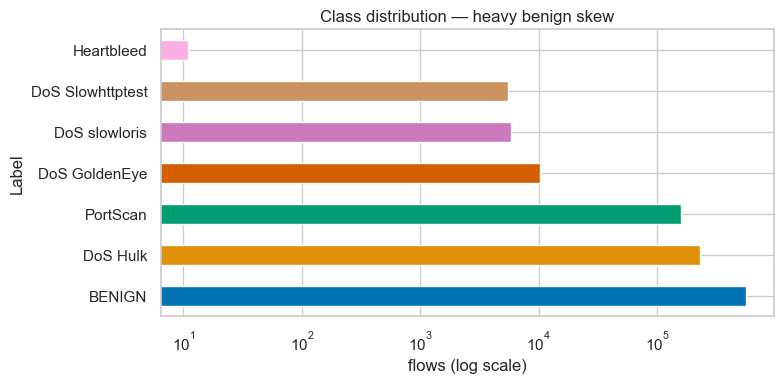

In [5]:
dist = df["Label"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
dist.plot.barh(ax=ax, logx=True, color=sns.color_palette("colorblind", len(dist)))
ax.set_xlabel("flows (log scale)"); ax.set_title("Class distribution — heavy benign skew")
plt.tight_layout()
dist.to_frame("count").assign(fraction=(dist / dist.sum()).round(4))

## OSI-layer feature mapping (`HX_LAYER_MAP`)

The core idea of HX: bucket flow features into Network / Transport / Application
layers. Features not in the map fall into a **cross-layer** bucket.

cross_layer          36
network_layer        11
application_layer    11
transport_layer      10
Name: count, dtype: int64

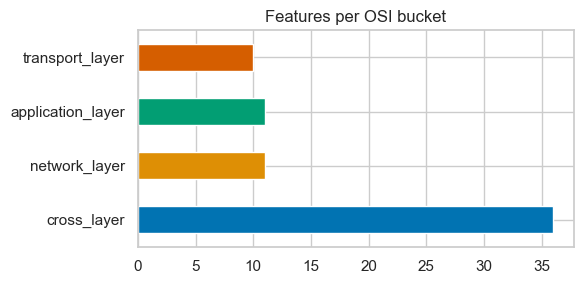

In [6]:
HX_LAYER_MAP = {
    "network_layer": [
        "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
        "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Mean",
        "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean",
        "Flow Bytes/s", "Flow Packets/s"],
    "transport_layer": [
        "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags",
        "FIN Flag Count", "SYN Flag Count", "RST Flag Count", "PSH Flag Count",
        "ACK Flag Count", "URG Flag Count", "Init_Win_bytes_forward",
        "Init_Win_bytes_backward", "min_seg_size_forward"],
    "application_layer": [
        "Average Packet Size", "Fwd Header Length", "Bwd Header Length",
        "Active Mean", "Active Std", "Active Max", "Active Min",
        "Idle Mean", "Idle Std", "Idle Max", "Idle Min"],
}
feat2layer = {f: l for l, feats in HX_LAYER_MAP.items() for f in feats}
features = [c for c in df.columns if c != "Label" and df[c].std() > 0]
assignment = pd.Series({f: feat2layer.get(f, "cross_layer") for f in features})
coverage = assignment.value_counts()
fig, ax = plt.subplots(figsize=(6, 3))
coverage.plot.barh(ax=ax, color=sns.color_palette("colorblind", 4))
ax.set_title("Features per OSI bucket"); plt.tight_layout()
coverage

> **Observation (drives ongoing work):** roughly half of the features land in
> `cross_layer` — the IAT statistics, subflow counts and bulk-rate features are not
> yet mapped. Extending the map is an open research task; the cross-layer bucket
> makes its cost visible rather than hiding it.

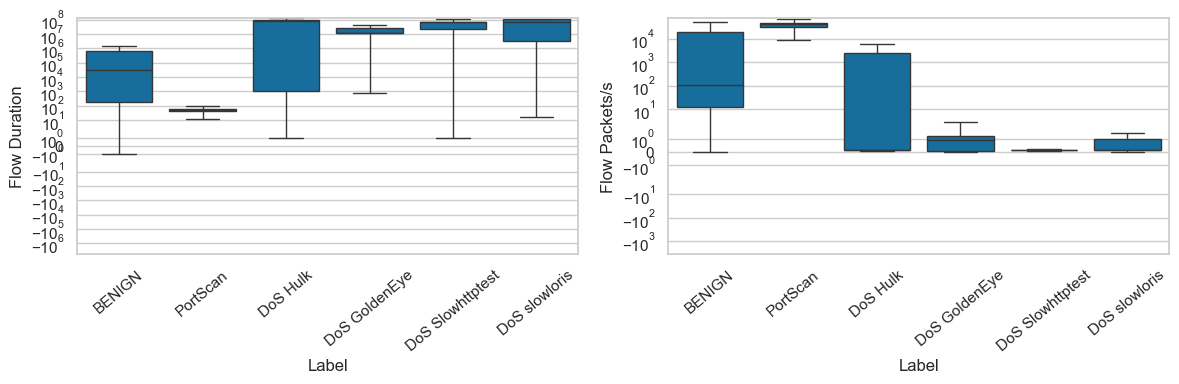

In [7]:
# Do attack classes visibly shift network-layer features? (sanity check)
sample = df.sample(min(30_000, len(df)), random_state=RANDOM_STATE)
show = ["Flow Duration", "Flow Packets/s"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, show):
    sns.boxplot(data=sample, x="Label", y=feat, ax=ax, showfliers=False)
    ax.set_yscale("symlog"); ax.tick_params(axis="x", rotation=40)
plt.tight_layout()

## Encode, split, scale 

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Stratified subsample: cap benign at 60k, attacks at 20k each (prototype scale)
caps = {"BENIGN": 60_000}
idx = np.concatenate([
    np.random.default_rng(RANDOM_STATE).choice(
        g.index, min(len(g), caps.get(lbl, 20_000)), replace=False)
    for lbl, g in df.groupby("Label")])
sub = df.loc[idx]
le = LabelEncoder()
y = le.fit_transform(sub["Label"])
X = sub[features].astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_train)          # fit on train only — no leakage
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
np.savez("proto_cache.npz",
         X_train=X_train.astype(np.float32), X_test=X_test.astype(np.float32),
         y_train=y_train, y_test=y_test,
         features=np.array(features), classes=le.classes_)
print("cached:", X_train.shape, "train /", X_test.shape, "test |", list(le.classes_))

cached: (97279, 68) train / (24320, 68) test | ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'Heartbleed', 'PortScan']
